# 训练损失曲线绘制

- 只需要修改 `RESULT_DIR` 即可切换实验目录。
- 从 `metrics.json` 读取并绘制所有 loss 到同一张图。
- 图像保存到 `RESULT_DIR/loss/loss_curves_all_in_one.png`。

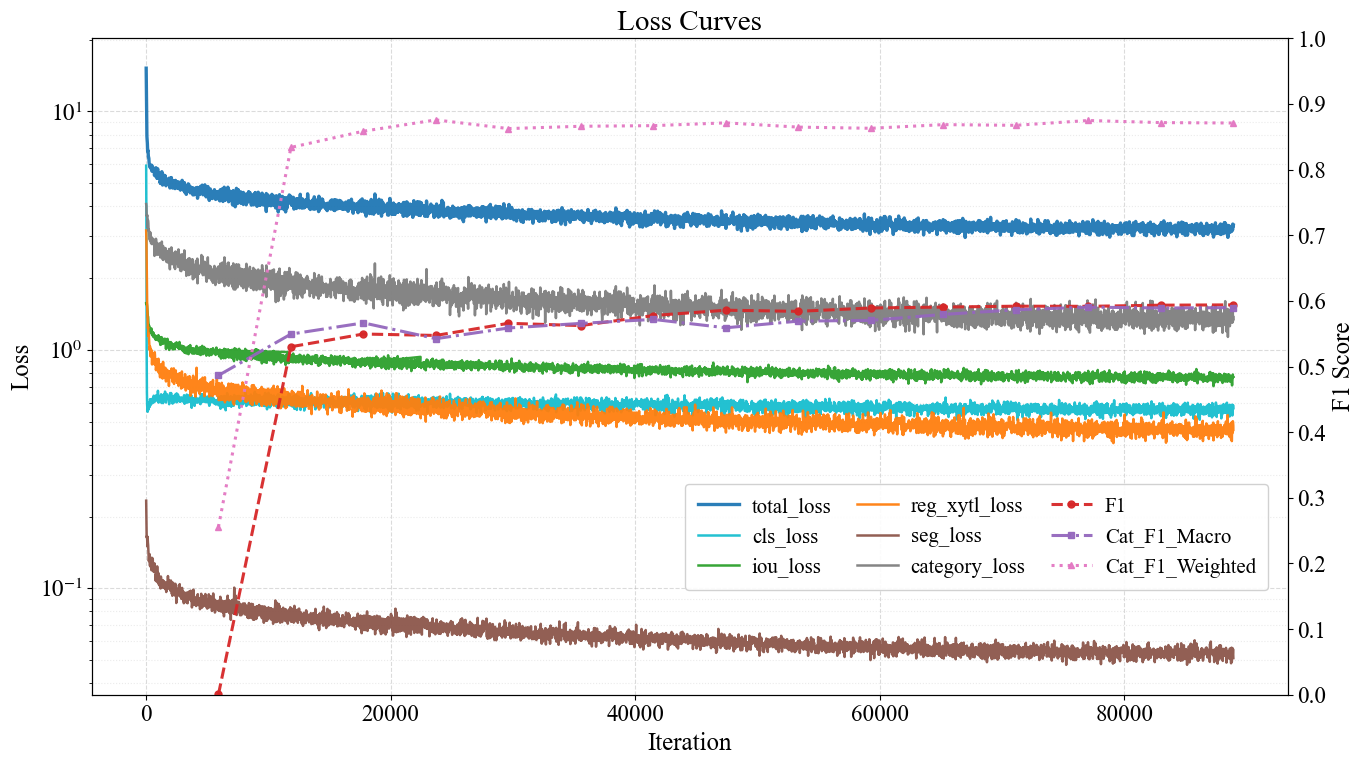

已保存: /data1/lxy_log/workspace/ms/UnLanedet/output/llanetv1/openlane1000/category/clrnet_combined_resnet34/loss/loss_curves_all_in_one.png


In [13]:
import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.ticker import FuncFormatter, LogLocator, NullFormatter

# ===================== 配置区（只改这里） =====================
RESULT_DIR = Path("output/llanetv1/openlane1000/category/clrnet_combined_resnet34")
START_ITER = None  # 例如 4000；None 表示不过滤
START_RATIO = 0.0  # 例如 0.2 表示从后 80% 迭代开始；当 START_ITER 不是 None 时该项忽略
Y_SCALE = "log"  # "log" 或 "linear"
FONT_SCALE = 1.5  # 全局字体放大倍数
PLOT_F1_ON_RIGHT_AXIS = True
F1_KEYS = ["F1", "Cat_F1_Macro", "Cat_F1_Weighted"]
# ============================================================

# 字体设置：优先按字体文件注册，避免 matplotlib 找不到 Times New Roman
for font_path in [
    "/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman.ttf",
    "/usr/share/fonts/truetype/msttcorefonts/times.ttf",
    "/usr/share/fonts/truetype/arphic/uming.ttc",
]:
    p = Path(font_path)
    if p.exists():
        try:
            font_manager.fontManager.addfont(str(p))
        except Exception:
            pass

# 这里把英文/数字优先放在前面；中文回退到 AR PL UMing CN
plt.rcParams["font.family"] = ["Times New Roman", "AR PL UMing CN", "DejaVu Sans"]
plt.rcParams["font.sans-serif"] = ["AR PL UMing CN", "DejaVu Sans"]
plt.rcParams["font.serif"] = ["Times New Roman", "DejaVu Serif"]
# 数学文本也尽量贴近 Times 风格
plt.rcParams["mathtext.fontset"] = "stix"
# 避免对数刻度中的负号使用 Unicode 字符，修复 10^-1 渲染异常
plt.rcParams["axes.unicode_minus"] = False

# 统一放大字体
base_font = 12 * FONT_SCALE
plt.rcParams["font.size"] = base_font
plt.rcParams["axes.titlesize"] = 14 * FONT_SCALE
plt.rcParams["axes.labelsize"] = 12 * FONT_SCALE
plt.rcParams["xtick.labelsize"] = 11 * FONT_SCALE
plt.rcParams["ytick.labelsize"] = 11 * FONT_SCALE
plt.rcParams["legend.fontsize"] = 10 * FONT_SCALE

# 兼容不同启动目录：自动向上寻找仓库根目录（以 output 和 tools 为标记）
def _find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "output").exists() and (p / "tools").exists():
            return p
    return start

repo_root = _find_repo_root(Path.cwd())
resolved_result_dir = RESULT_DIR if RESULT_DIR.is_absolute() else (repo_root / RESULT_DIR)
resolved_result_dir = resolved_result_dir.resolve()

metrics_file = resolved_result_dir / "metrics.json"
save_dir = resolved_result_dir / "loss"
save_dir.mkdir(parents=True, exist_ok=True)
save_path = save_dir / "loss_curves_all_in_one.png"

if not metrics_file.exists():
    raise FileNotFoundError(
        f"未找到文件: {metrics_file}\n"
        f"当前工作目录: {Path.cwd()}\n"
        f"自动识别仓库根目录: {repo_root}\n"
        "请检查 RESULT_DIR 是否正确。"
    )

# metrics.json 为 jsonl：每行一个 JSON
records = []
with metrics_file.open("r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        try:
            records.append(json.loads(line))
        except json.JSONDecodeError:
            # 忽略异常行，保证绘图不中断
            continue

if not records:
    raise RuntimeError(f"{metrics_file} 中没有可用记录")

loss_keys = [
    "total_loss",
    "cls_loss",
    "iou_loss",
    "reg_xytl_loss",
    "seg_loss",
    "category_loss",
]

# 训练损失序列
loss_records = [r for r in records if "total_loss" in r]
x = [r.get("iteration", i + 1) for i, r in enumerate(loss_records)]
series = {k: [] for k in loss_keys}
for rec in loss_records:
    for k in loss_keys:
        v = rec.get(k)
        series[k].append(float(v) if isinstance(v, (int, float)) else float("nan"))

# 评估 F1 序列（通常是按 checkpoint 周期记录）
f1_records = [r for r in records if all(k in r for k in F1_KEYS)]
f1_x = [r.get("iteration") for r in f1_records if isinstance(r.get("iteration"), (int, float))]
f1_series = {
    k: [float(r[k]) for r in f1_records if isinstance(r.get("iteration"), (int, float))]
    for k in F1_KEYS
}

# 按起始位置过滤，避免前期大损失淹没后期细节
if START_ITER is not None:
    start_idx = next((i for i, it in enumerate(x) if it >= START_ITER), len(x) - 1)
elif START_RATIO > 0:
    start_idx = min(max(int(len(x) * START_RATIO), 0), max(len(x) - 1, 0))
else:
    start_idx = 0

x_plot = x[start_idx:]
series_plot = {k: v[start_idx:] for k, v in series.items()}

# F1 同步按 iteration 截断
if x_plot:
    f1_start_it = x_plot[0]
    f1_keep = [i for i, it in enumerate(f1_x) if it >= f1_start_it]
    f1_x_plot = [f1_x[i] for i in f1_keep]
    f1_series_plot = {k: [vals[i] for i in f1_keep] for k, vals in f1_series.items()}
else:
    f1_x_plot = f1_x
    f1_series_plot = f1_series

fig, ax = plt.subplots(figsize=(14, 8))

# 避免颜色重复：loss 与 F1 使用两套互不重叠的色板
loss_style = {
    "total_loss": {"color": "#1f77b4", "linestyle": "-", "linewidth": 2.4},
    "cls_loss": {"color": "#17becf", "linestyle": "-", "linewidth": 1.8},
    "iou_loss": {"color": "#2ca02c", "linestyle": "-", "linewidth": 1.8},
    "reg_xytl_loss": {"color": "#ff7f0e", "linestyle": "-", "linewidth": 1.8},
    "seg_loss": {"color": "#8c564b", "linestyle": "-", "linewidth": 1.8},
    "category_loss": {"color": "#7f7f7f", "linestyle": "-", "linewidth": 1.8},
}

for k in loss_keys:
    if all(v != v for v in series_plot[k]):  # 全 NaN 则不画
        continue
    style = loss_style.get(k, {})
    ax.plot(x_plot, series_plot[k], label=k, alpha=0.95, **style)

ax.set_xlabel("Iteration")
ax.set_ylabel("Loss")

if Y_SCALE == "log":
    ax.set_yscale("log")
    # 主刻度显示 10^n，次刻度加密并保留网格，便于观察后期细节
    ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=15))

    def _fmt_power_of_ten(y, _):
        if y <= 0:
            return ""
        exp = int(round(math.log10(y)))
        # 这里使用普通连字符 '-'，避免 Unicode 负号渲染问题
        return rf"$10^{{{exp}}}$"

    ax.yaxis.set_major_formatter(FuncFormatter(_fmt_power_of_ten))
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=(2, 3, 4, 5, 6, 7, 8, 9), numticks=200))
    ax.yaxis.set_minor_formatter(NullFormatter())

# 右轴添加 F1 曲线
ax2 = None
if PLOT_F1_ON_RIGHT_AXIS and f1_x_plot:
    ax2 = ax.twinx()
    f1_style = {
        "F1": {"color": "#d62728", "linestyle": "--", "marker": "o"},
        "Cat_F1_Macro": {"color": "#9467bd", "linestyle": "-.", "marker": "s"},
        "Cat_F1_Weighted": {"color": "#e377c2", "linestyle": ":", "marker": "^"},
    }
    for k in F1_KEYS:
        vals = f1_series_plot.get(k, [])
        if not vals:
            continue
        style = f1_style.get(k, {})
        ax2.plot(
            f1_x_plot,
            vals,
            label=k,
            linewidth=2.2,
            markersize=5,
            markevery=max(1, len(f1_x_plot) // 12),
            alpha=0.95,
            **style,
        )
    ax2.set_ylabel("F1 Score")
    ax2.set_ylim(0.0, 1.0)
    ax2.set_yticks([i / 10 for i in range(0, 11)])

# 合并图例并放到图内右侧空白区（右轴约 0.1~0.4 区域）
if ax2 is not None:
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    handles = lines1 + lines2
    labels = labels1 + labels2
else:
    handles, labels = ax.get_legend_handles_labels()

ax.legend(
    handles,
    labels,
    loc="center",
    bbox_to_anchor=(0.74, 0.24),
    ncol=3,
    frameon=True,
    framealpha=0.9,
    borderpad=0.6,
    columnspacing=1.2,
    handletextpad=0.6,
)

plt.title("Loss Curves")
ax.grid(True, which="major", linestyle="--", alpha=0.45)
ax.grid(True, which="minor", linestyle=":", alpha=0.25)
plt.tight_layout()

plt.savefig(save_path, dpi=300)
plt.show()
print(f"已保存: {save_path}")
